In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split


In [15]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = 'DL_PA2/processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [10]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [16]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# Ensure data is unzipped before loading
!unzip -o /content/DL_PA2.zip

# Redefine DATA_DIR and TRAIN_FILE to ensure current values are used
DATA_DIR = 'DL_PA2/processed_data'
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Archive:  /content/DL_PA2.zip
  inflating: __MACOSX/._DL_PA2       
  inflating: DL_PA2/.DS_Store        
  inflating: __MACOSX/DL_PA2/._.DS_Store  
  inflating: DL_PA2/<roll_num>_PA2.ipynb  
  inflating: __MACOSX/DL_PA2/._<roll_num>_PA2.ipynb  
  inflating: __MACOSX/DL_PA2/._processed_data  
  inflating: DL_PA2/processed_data/quickdraw_train.npz  
  inflating: __MACOSX/DL_PA2/processed_data/._quickdraw_train.npz  
  inflating: DL_PA2/processed_data/.DS_Store  
  inflating: __MACOSX/DL_PA2/processed_data/._.DS_Store  
  inflating: DL_PA2/processed_data/quickdraw_test.npz  
  inflating: __MACOSX/DL_PA2/processed_data/._quickdraw_test.npz  
Loading train data from DL_PA2/processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [17]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================
# ==========================================
# 4.1 THE PANCAKE (Width Focus)
# ==========================================
class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(PancakeMLP, self).__init__()
        # Hidden Layers: 1 or 2 [cite: 45]
        # Neurons per layer: High (e.g., 2048) [cite: 46]
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 2048),
            nn.ReLU(),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ==========================================
# 4.2 THE TOWER (Depth Focus)
# ==========================================
class TowerMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(TowerMLP, self).__init__()
        # Hidden Layers: 5 or more [cite: 50]
        # Neurons per layer: Low (e.g., 128 or 256) [cite: 51]
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256), # Encouraged for deep networks [cite: 53]
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ==========================================
# 4.3 THE CHAMPION (Leaderboard Submission)
# ==========================================
class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        # Design choice: Balancing depth with regularization to combat overfitting [cite: 55, 130]
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(), # GELU can help avoid dead neurons [cite: 55, 128]
            nn.Dropout(0.3), # Dropout helps generalize [cite: 55, 130]

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Instantiate your model (Select which one to train)
model = ChampionMLP(num_classes=NUM_CLASSES).to(DEVICE)


In [23]:
# ==========================================
# COMPLETE TRAINING EXECUTION
# ==========================================

def train_model(model_name, model_obj, train_loader, val_loader, epochs=10):
    print(f"\n>>> Starting Training: {model_name}")
    model_obj.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    # Using Adam optimizer as suggested for the "Champion" and general MLP training [cite: 134]
    optimizer = optim.Adam(model_obj.parameters(), lr=0.001)

    stats = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model_obj.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model_obj(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluation phase for validation accuracy [cite: 48, 67]
        model_obj.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model_obj(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_acc = 100 * correct / total
        epoch_loss = running_loss / len(train_loader)
        stats['train_loss'].append(epoch_loss)
        stats['val_acc'].append(epoch_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.2f}%")

    return stats

# --- Train Part A: The Pancake ---
pancake_model = PancakeMLP(num_classes=NUM_CLASSES).to(DEVICE)
pancake_results = train_model("Pancake (Width Focus)", pancake_model, train_loader, val_loader, epochs=10)

# --- Train Part B: The Tower ---
tower_model = TowerMLP(num_classes=NUM_CLASSES).to(DEVICE)
tower_results = train_model("Tower (Depth Focus)", tower_model, train_loader, val_loader, epochs=10)

# --- Train Part C: The Champion ---
champion_model = ChampionMLP(num_classes=NUM_CLASSES).to(DEVICE)
champion_results = train_model("Champion (Leaderboard)", champion_model, train_loader, val_loader, epochs=20)

model = champion_model


>>> Starting Training: Pancake (Width Focus)
Epoch [1/10] - Loss: 1.1521 | Val Acc: 69.88%
Epoch [2/10] - Loss: 0.8255 | Val Acc: 73.69%
Epoch [3/10] - Loss: 0.6793 | Val Acc: 74.85%
Epoch [4/10] - Loss: 0.5675 | Val Acc: 75.96%
Epoch [5/10] - Loss: 0.4679 | Val Acc: 75.94%
Epoch [6/10] - Loss: 0.3831 | Val Acc: 76.88%
Epoch [7/10] - Loss: 0.3043 | Val Acc: 76.29%
Epoch [8/10] - Loss: 0.2284 | Val Acc: 76.90%
Epoch [9/10] - Loss: 0.1648 | Val Acc: 76.58%
Epoch [10/10] - Loss: 0.1175 | Val Acc: 76.31%

>>> Starting Training: Tower (Depth Focus)
Epoch [1/10] - Loss: 1.0654 | Val Acc: 71.58%
Epoch [2/10] - Loss: 0.7723 | Val Acc: 74.33%
Epoch [3/10] - Loss: 0.6626 | Val Acc: 75.40%
Epoch [4/10] - Loss: 0.5842 | Val Acc: 75.86%
Epoch [5/10] - Loss: 0.5210 | Val Acc: 76.38%
Epoch [6/10] - Loss: 0.4628 | Val Acc: 75.83%
Epoch [7/10] - Loss: 0.4140 | Val Acc: 76.64%
Epoch [8/10] - Loss: 0.3630 | Val Acc: 76.29%
Epoch [9/10] - Loss: 0.3265 | Val Acc: 75.88%
Epoch [10/10] - Loss: 0.2943 | Val 

In [24]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from DL_PA2/processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [25]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 1,467,407
  ✅ Parameter count is within limits.


In [26]:
pancake_model = PancakeMLP(num_classes=NUM_CLASSES).to(DEVICE)
tower_model = TowerMLP(num_classes=NUM_CLASSES).to(DEVICE)

print("--- PANCAKE MODEL STATISTICS ---")
print_model_size(pancake_model)

print("\n--- TOWER MODEL STATISTICS ---")
print_model_size(tower_model)

--- PANCAKE MODEL STATISTICS ---

Model Statistics:
  Total Parameters: 1,638,415
  ✅ Parameter count is within limits.

--- TOWER MODEL STATISTICS ---

Model Statistics:
  Total Parameters: 385,935
  ✅ Parameter count is within limits.


<Figure size 1000x800 with 0 Axes>

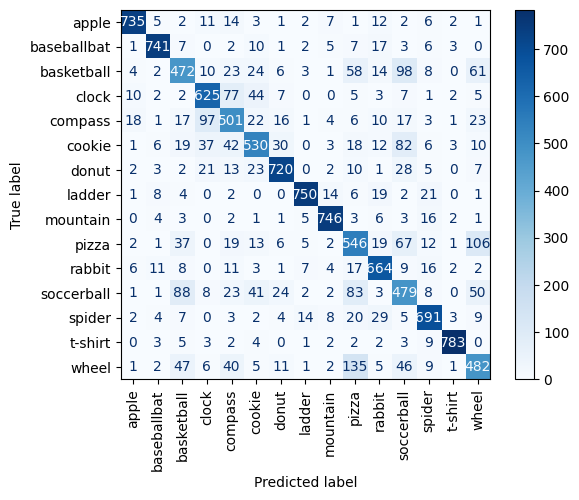

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def analyze_confusion(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(DEVICE))
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(xticks_rotation='vertical', cmap='Blues')
    plt.show()

analyze_confusion(model, val_loader)

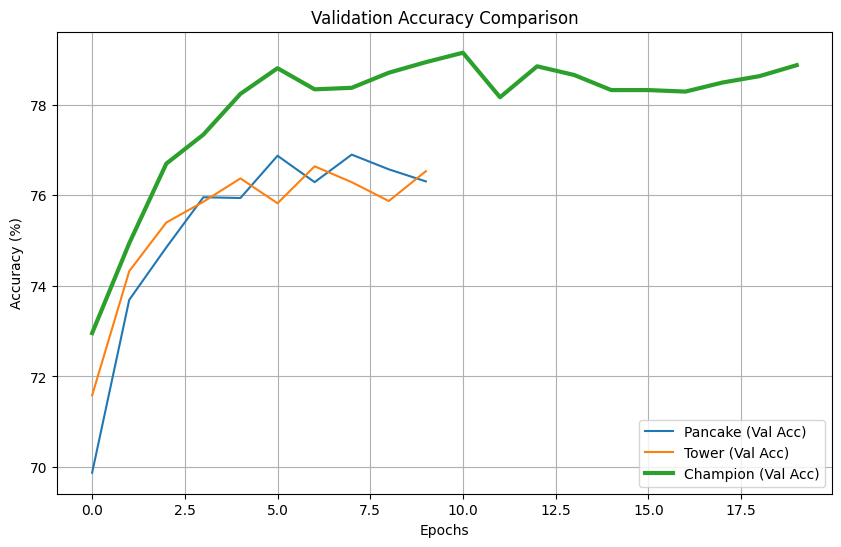

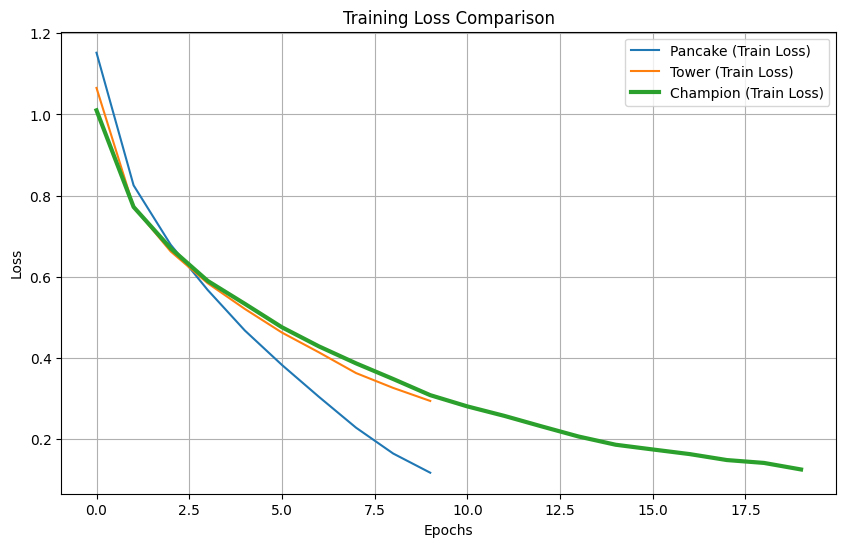

In [28]:
import matplotlib.pyplot as plt

# 1. Accuracy Curves
plt.figure(figsize=(10, 6))
plt.plot(pancake_results['val_acc'], label='Pancake (Val Acc)')
plt.plot(tower_results['val_acc'], label='Tower (Val Acc)')
plt.plot(champion_results['val_acc'], label='Champion (Val Acc)', linewidth=3)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(pancake_results['train_loss'], label='Pancake (Train Loss)')
plt.plot(tower_results['train_loss'], label='Tower (Train Loss)')
plt.plot(champion_results['train_loss'], label='Champion (Train Loss)', linewidth=3)
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()